<a href="https://colab.research.google.com/github/juanpajaro/IA_en_salud_diplomado_puj/blob/main/Clase_4_Prediccion_enfermedad_cardiaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**INTRODUCCIÓN**

Las enfermedades cardíacas, también conocidas como enfermedades cardiovasculares, es un término amplio utilizado para describir enfermedades y condiciones que afectan el corazón y el sistema circulatorio. Es una de las principales causas de discapacidad en todo el mundo. Dado que el corazón se encuentra entre los órganos más vitales del cuerpo, sus enfermedades también afectan a otros órganos y partes del cuerpo. Existen varios tipos y formas diferentes de enfermedades cardíacas. Las más comunes causan estrechamiento u obstrucción de las arterias coronarias, mal funcionamiento de las válvulas del corazón, agrandamiento del tamaño del corazón y varias otras que conducen a insuficiencia cardíaca y ataque cardíaco.

![Enfermedad cardiaca](https://www.indushealthplus.com/front/media/article_img/heart-disease-thumb.jpg)

### Datos clave según la OMS (Organización Mundial de la Salud)

* **Principal causa de muerte:** Las enfermedades cardiovasculares (ECV) son la principal causa de muerte en todo el mundo.
* **Estadísticas de mortalidad:** Se estima que 17,9 millones de personas murieron por ECV en 2019, lo que representa el **32% de todas las muertes globales**. De estas muertes, el 85% se debieron a ataques cardíacos y accidentes cerebrovasculares.
* **Impacto en países en desarrollo:** Más de tres cuartas partes de las muertes por ECV ocurren en países de ingresos bajos y medios.
* **Muertes prematuras:** De las 17 millones de muertes prematuras (menores de 70 años) atribuidas a enfermedades no transmisibles en 2019, el **38% fueron causadas por ECV**.
* **Prevención:** La mayoría de las enfermedades cardiovasculares pueden prevenirse abordando factores de riesgo conductuales como el consumo de tabaco, las dietas poco saludables, la obesidad, la inactividad física y el consumo nocivo de alcohol.
* **Detección temprana:** Es fundamental detectar las enfermedades cardiovasculares lo antes posible para iniciar el tratamiento mediante asesoramiento y medicación.

##Librerias

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from IPython.core.display import HTML
import matplotlib.pyplot as plt
from scipy.stats import uniform

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import recall_score, accuracy_score,roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.preprocessing import LabelEncoder
import shap

#**1. Cargue de datos**







In [3]:
data = pd.read_csv("heart.csv")

#**2. Ajuste de datos**

In [4]:
data = data[data['ca'] < 4] #drop the wrong ca values
data = data[data['thal'] > 0] # drop the wong thal value
print(f'The length of the data now is {len(data)} instead of 303!')

The length of the data now is 296 instead of 303!


In [5]:
data = data.rename(
    columns = {'cp':'chest_pain_type',
               'trestbps':'resting_blood_pressure',
               'chol': 'cholesterol',
               'fbs': 'fasting_blood_sugar',
               'restecg' : 'resting_electrocardiogram',
               'thalach': 'max_heart_rate_achieved',
               'exang': 'exercise_induced_angina',
               'oldpeak': 'st_depression',
               'slope': 'st_slope',
               'ca':'num_major_vessels',
               'thal': 'thalassemia'},
    errors="raise")

In [6]:
data['sex'][data['sex'] == 0] = 'female'
data['sex'][data['sex'] == 1] = 'male'

data['chest_pain_type'][data['chest_pain_type'] == 0] = 'typical angina'
data['chest_pain_type'][data['chest_pain_type'] == 1] = 'atypical angina'
data['chest_pain_type'][data['chest_pain_type'] == 2] = 'non-anginal pain'
data['chest_pain_type'][data['chest_pain_type'] == 3] = 'asymptomatic'

data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 1] = 'greater than 120mg/ml'

data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 0] = 'normal'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 1] = 'ST-T wave abnormality'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 2] = 'left ventricular hypertrophy'

data['exercise_induced_angina'][data['exercise_induced_angina'] == 0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina'] == 1] = 'yes'

data['st_slope'][data['st_slope'] == 0] = 'upsloping'
data['st_slope'][data['st_slope'] == 1] = 'flat'
data['st_slope'][data['st_slope'] == 2] = 'downsloping'

data['thalassemia'][data['thalassemia'] == 1] = 'fixed defect'
data['thalassemia'][data['thalassemia'] == 2] = 'normal'
data['thalassemia'][data['thalassemia'] == 3] = 'reversable defect'

#**3 Gestion de datos**

##**3.1 Tipo de datos**

In [7]:
data.shape

(296, 14)

In [8]:
data.dtypes

,0
age,int64
sex,object
chest_pain_type,object
resting_blood_pressure,int64
cholesterol,int64
fasting_blood_sugar,object
resting_electrocardiogram,object
max_heart_rate_achieved,int64
exercise_induced_angina,object
st_depression,float64


In [9]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,greater than 120mg/ml,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


In [10]:
# numerical fearures 6
num_feats = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']
# categorical (binary)
bin_feats = ['sex', 'fasting_blood_sugar', 'exercise_induced_angina', 'target']
# caterorical (multi-)
nom_feats= ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia']
cat_feats = nom_feats + bin_feats

##3.2 Distribución de la variable objetivo
La variable objetivo esta balanceada (~46% sin cardiopatía y ~54% con ella)

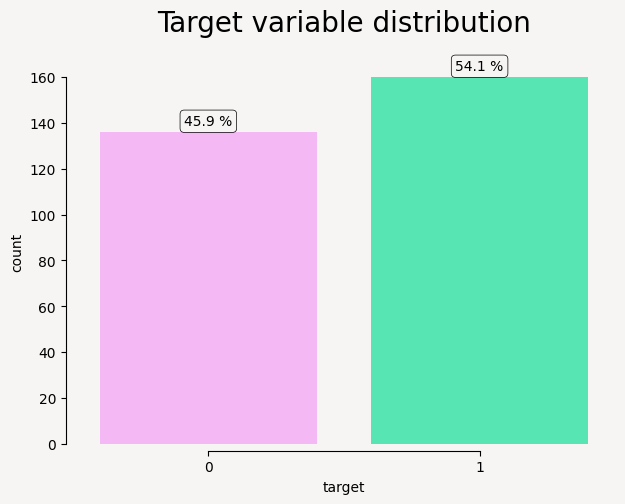

In [11]:
mypal= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA']

plt.figure(figsize=(7, 5),facecolor='#F6F5F4')
total = float(len(data))
ax = sns.countplot(x=data['target'], palette=mypal[1::4])
ax.set_facecolor('#F6F5F4')

for p in ax.patches:

    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.1f} %'.format((height/total)*100), ha="center",
           bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

ax.set_title('Target variable distribution', fontsize=20, y=1.05)
sns.despine(right=True)
sns.despine(offset=5, trim=True)

##3.3 Variables numericas


In [12]:
data[num_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
cholesterol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
resting_blood_pressure,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
max_heart_rate_achieved,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
st_depression,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2
num_major_vessels,296.0,0.679054,0.939726,0.0,0.0,0.0,1.00,3.0


### Resumen estadístico variables numericas
* **Edad:**
    * La edad promedio en el conjunto de datos es de 54.5 años.
    * La edad máxima registrada es de 77 años, mientras que la mínima es de 29 años.
* **Colesterol:**
    * El nivel promedio de colesterol registrado es de 247.15 mg/dl (miligramos por decilitro).
    * El nivel máximo es de 564 mg/dl y el mínimo es de 126 mg/dl.
    * *Nota:* Según la literatura médica, un nivel saludable de colesterol es < 200 mg/dl; niveles elevados suelen estar asociados con enfermedades cardíacas.
* **Presión Arterial en Reposo:**
    * Media: 131 mmHg (milimetros de mercurio) | Máxima: 200 mmHg | Mínima: 94 mmHg.
* **Frecuencia Cardíaca Máxima Alcanzada:**
    * El promedio registrado es de 149.5 lpm (latidos por minuto).
    * El valor máximo es de 202 lpm y el mínimo es de 71 lpm.
* **Depresión del Segmento ST (St_depression):**
    * El valor promedio es de 1.06. El máximo es de 6.2 y el mínimo es 0.
* **Número de Vasos Sanguíneos Principales:**
    * Se observa un máximo de 3 vasos y un mínimo de 0.
    * El valor medio es de 0.68.

![Depresión del Segmento ST](https://cvphysiology.com/s9v2f-3r4p7/share/CAD012%20ECG%20ST%20depression.png)

![Elevación del Segmento ST](https://cvphysiology.com/s9v2f-3r4p7/share/CAD012%20ST%20elevation.png)

> **Interpretación Clínica:** La imagen superior muestra la morfología normal del ECG comparada con la elevación y depresión del segmento ST, marcadores clave para identificar isquemia o infarto miocárdico en el conjunto de datos.

##**3.4 Variables categoricas**

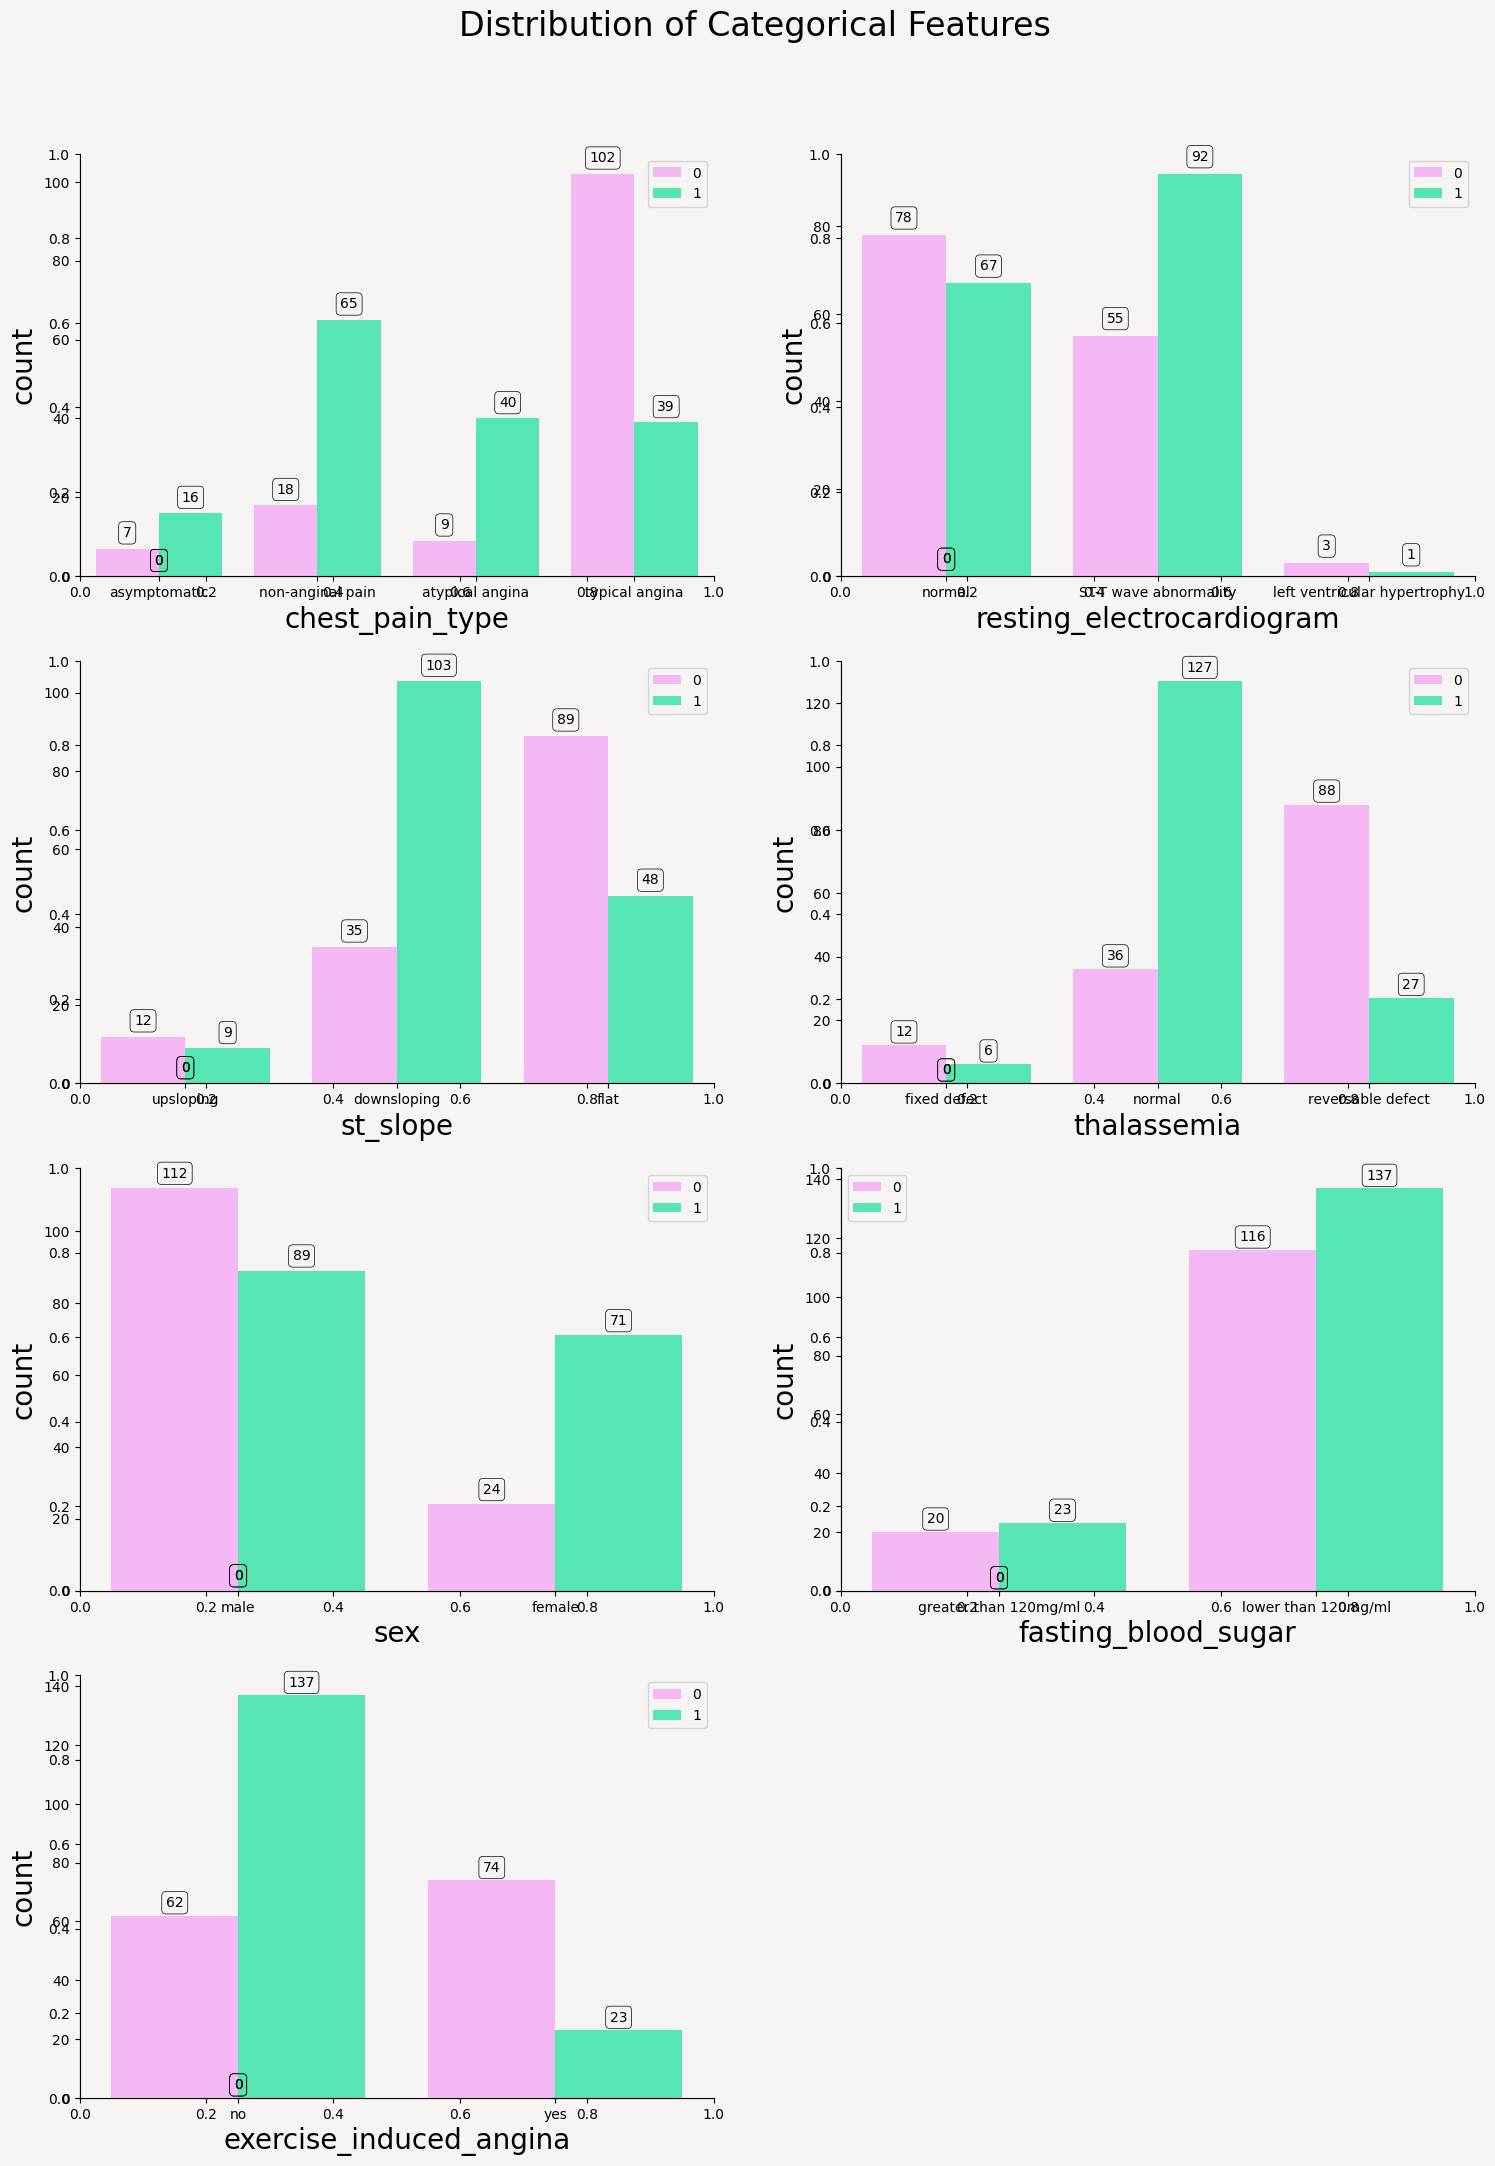

In [13]:
def count_plot(data, cat_feats):
    L = len(cat_feats)
    ncol= 2
    nrow= int(np.ceil(L/ncol))
    remove_last= (nrow * ncol) - L

    fig, ax = plt.subplots(nrow, ncol,figsize=(18, 24), facecolor='#F6F5F4')
    fig.subplots_adjust(top=0.92)
    ax.flat[-remove_last].set_visible(False)

    i = 1
    for col in cat_feats:
        plt.subplot(nrow, ncol, i, facecolor='#F6F5F4')
        ax = sns.countplot(data=data, x=col, hue="target", palette=mypal[1::4])
        ax.set_xlabel(col, fontsize=20)
        ax.set_ylabel("count", fontsize=20)
        sns.despine(right=True)
        sns.despine(offset=0, trim=False)
        plt.legend(facecolor='#F6F5F4')

        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.0f}'.format((height)),ha="center",
                  bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

        i = i +1

    plt.suptitle('Distribution of Categorical Features' ,fontsize = 24)
    return 0

count_plot(data, cat_feats[0:-1]);

In [28]:
age_bins = [10*i for i in range(3, 9)] # Bins from 20-30, 30-40, ..., 70-80
age_labels = [f'{i}-{i+9}' for i in age_bins[:-1]] # Labels like '20-29', '30-39'
data['age_group'] = pd.cut(data['age'], bins=age_bins, labels=age_labels, right=False)

# Adjusting bins for 5-year intervals as requested by user
age_bins_5 = list(range(25, 85, 5)) # Start from 25, end before 85, step 5
age_labels_5 = [f'{i}-{i+4}' for i in age_bins_5[:-1]]
data['age_group_5'] = pd.cut(data['age'], bins=age_bins_5, labels=age_labels_5, right=False)

# Display the first few rows with the new age_group_5 column
display(data[['age', 'age_group_5']].head())

,age,age_group_5
0,63,60-64
1,37,35-39
2,41,40-44
3,56,55-59
4,57,55-59


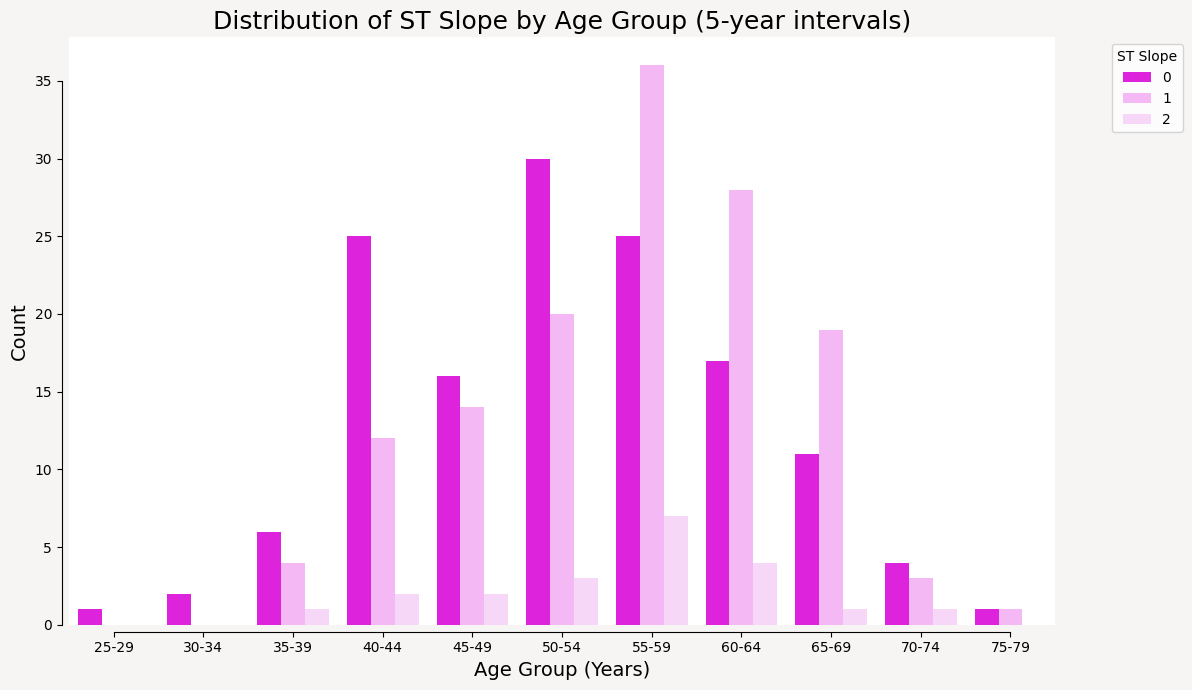

In [30]:
plt.figure(figsize=(12, 7), facecolor='#F6F5F4')
sns.countplot(data=data, x='age_group_5', hue='st_slope', palette=mypal[0:3])
plt.title('Distribution of ST Slope by Age Group (5-year intervals)', fontsize=18)
plt.xlabel('Age Group (Years)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='ST Slope', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(right=True)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.show()

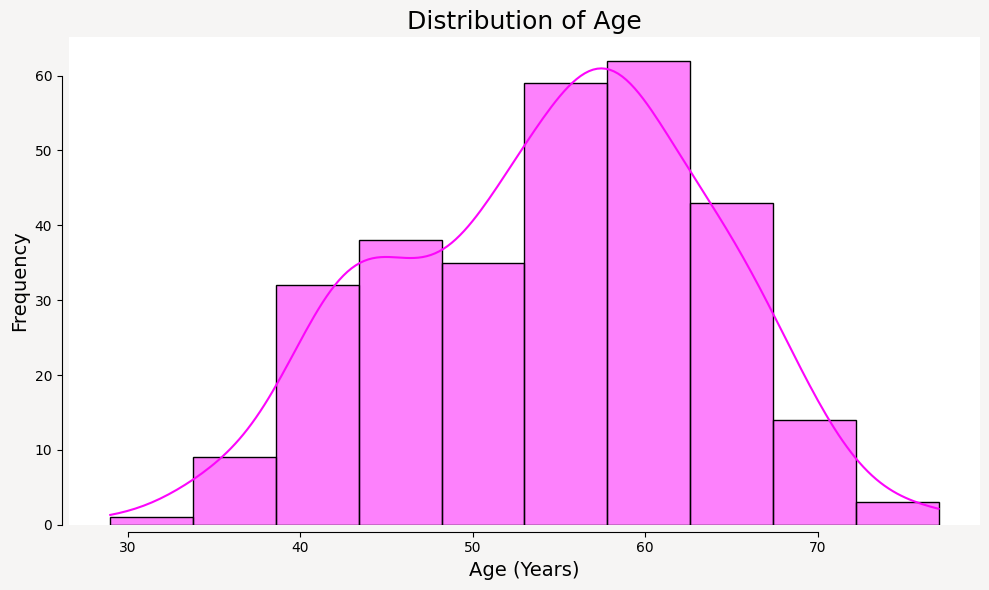

In [37]:
plt.figure(figsize=(10, 6), facecolor='#F6F5F4')
sns.histplot(data=data, x='age', bins=10, kde=True, color=mypal[0])
plt.title('Distribution of Age', fontsize=18)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
sns.despine(right=True)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.show()

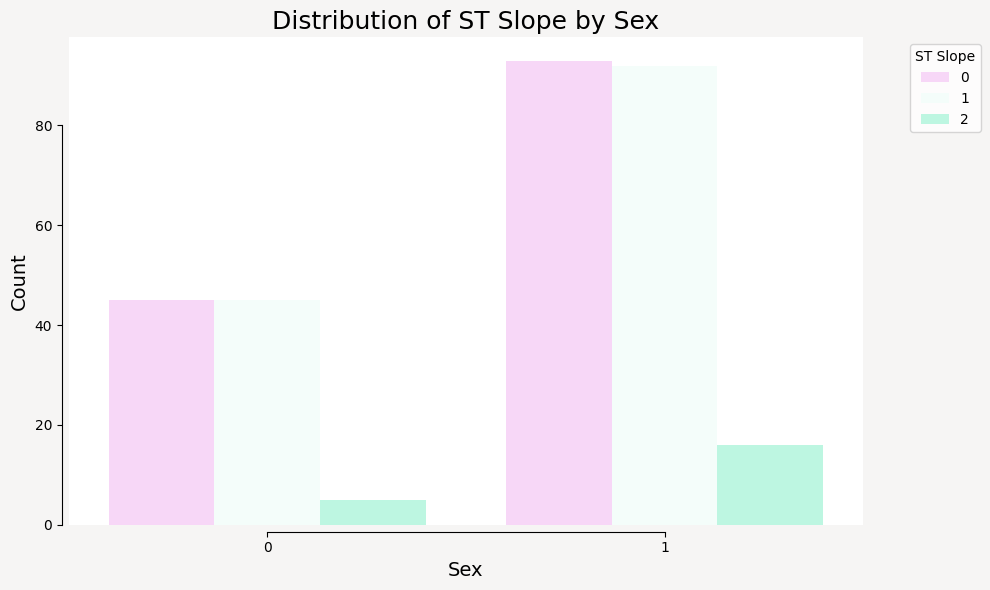

In [39]:
plt.figure(figsize=(10, 6), facecolor='#F6F5F4')
sns.countplot(data=data, x='sex', hue='st_slope', palette=mypal[2:5]) # Using a different slice of mypal
plt.title('Distribution of ST Slope by Sex', fontsize=18)
plt.xlabel('Sex', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='ST Slope', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(right=True)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.show()

### Análisis de Variables Clínicas

* **Dolor en el Pecho (Chest Pain):**    
    * Los pacientes que presentaron angina atípica o dolor no anginoso tienen mayor probabilidad de padecer una enfermedad cardíaca.

* **Electrocardiograma en Reposo (REC):**
    * Los pacientes con hipertrofia ventricular izquierda son la minoría (~1.4%). El resto se divide casi equitativamente entre aquellos con anomalías del segmento ST-T y pruebas normales.
    * Las anomalías del ST-T parecen tener una mejor correlación con la variable objetivo; la mayoría de los pacientes con este resultado terminaron con una enfermedad cardíaca.

* **Pendiente del Segmento ST (ST-Slope):**
    * La mayoría de los pacientes presentan una pendiente descendente o plana.
    * Las pendientes descendentes son un fuerte indicio de que el paciente podría tener una enfermedad cardíaca.

* **Talasemia:**
    * La mayoría de los pacientes tienen un resultado normal o un defecto reversible.
    * Curiosamente, los pacientes con defectos de talasemia (reversibles + fijos) tienen menos probabilidades de tener una enfermedad cardíaca, mientras que aquellos con talasemia normal tienen más probabilidades. Este resultado parece no ser intuitivo.

* **Glucemia en Ayunas (Fasting Blood Sugar):**
    * Los pacientes con niveles bajos de azúcar en sangre (menos de 120 mg/dl) son la mayoría, representando aproximadamente el 85% de la muestra.
    

* **Angina Inducida por el Ejercicio:**
    * Dos tercios de los pacientes no mostraron angina inducida por el ejercicio.
    * El 76% de los pacientes con angina inducida por ejercicio no tenían afecciones cardíacas. En contraste, el ~69% de quienes no la experimentaron fueron diagnosticados con una condición cardíaca.

* **Sexo:**
    * La muestra cuenta con una mayor cantidad de pacientes hombres.
    * Sin embargo, las mujeres parecen sufrir de condiciones cardíacas en mayor proporción que los hombres en este conjunto de datos.

##**3.5 Conclusiones gestión de datos**

* **¿Cuantos pacientes hay?**
  * 296
* **¿Hay valores perdidos?**
  * No hay valores perdidos.
* **¿Cuantas variables numericas y categoricas existen?**
  * 6 numericas y 7 categoricas
* **¿La variable objetivo esta balanceada?**
  * Si
* **¿Cuales son las variables que mejor pueden predecir la enfermedad cardiaca?**
  * Ejemplo: tipo de dolor torácico, Presión arterial sistolica, Azucar en sangre, sexo


##**3.6 Codificacion de las variables**

In [14]:
def label_encode_cat_features(data, cat_features):
    '''
    Given a dataframe and its categorical features, this function returns label-encoded dataframe
    '''

    label_encoder = LabelEncoder()
    data_encoded = data.copy()

    for col in cat_features:
        data_encoded[col] = label_encoder.fit_transform(data[col])

    data = data_encoded

    return data


In [15]:
# split the data into train and test sets

cat_features = cat_feats
data = label_encode_cat_features(data, cat_features)

seed = 0
test_size = 0.25

features = data.columns[:-1]

X = data[features]
y = data['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = test_size, random_state=seed)

#**4 Regresion logistica**

### 4.1 Principios de la función
La función de la regresión logística utiliza la función sigmoide para mapear los resultados a un rango entre 0 y 1:

$$h_\theta(x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Donde:
* $w^T x + b$ es la combinación lineal de las entradas y los parámetros (pesos y sesgo).
* $\sigma$ representa la función logística o sigmoide.
* $e$ es la constante de Euler o simplemente el numero $e$ (aprox. 2.718).

#### 4.1.1 Interpretación de la función

Al usar la estructura de la función sigmoide, el modelo asegura que la salida sea una probabilidad.

* Si el valor de $z$ es muy grande y positivo, $e^{-z}$ tiende a 0, por lo que $h(x)$ se acerca a 1.
* Si el valor de $z$ es muy grande y negativo, $e^{-z}$ tiende a infinito, por lo que $h(x)$ se acerca a 0.

El valor de $z$ es la computación de las variables del modelo:

$$h_\theta(x) = \frac{1}{1 + e^{-z}}$$
donde $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$


![función sigmoide](https://upload.wikimedia.org/wikipedia/commons/thumb/6/66/Funci%C3%B3n_sigmoide_01.svg/1280px-Funci%C3%B3n_sigmoide_01.svg.png)

### 4.2 Función de Pérdida: Entropía Cruzada Binaria (Log Loss)

En la regresión logística, no usamos el Error Cuadrático Medio porque la función sigmoide generaría una superficie no convexa (con muchos "valles" falsos). En su lugar, usamos la Log Loss, que mide la diferencia entre la probabilidad predicha $h_\theta(x)$ y el valor real $y \in \{0, 1\}$.
Para un solo ejemplo de entrenamiento, la pérdida se define como:

$$Loss(h_\theta(x), y) = \begin{cases} -\log(h_\theta(x)) & \text{si } y = 1 \\ -\log(1 - h_\theta(x)) & \text{si } y = 0 \end{cases}$$


#### 4.2.1 Fórmula General (Función de Costo $J(\theta)$)

Para optimizar el modelo sobre todo el conjunto de datos ($m$ ejemplos), combinamos ambas condiciones en una sola ecuación:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$

**¿Por qué funciona esta lógica?**

* Si el valor real es $y=1$: Cuando el modelo predice algo cercano a 1, el $-\log(1)$ es casi 0 (poca pérdida). Pero si el modelo predice algo cercano a 0, el $-\log$ crece hacia el infinito, penalizando fuertemente el error.
* Si el valor real es $y=0$: El segundo término de la ecuación se activa. Si el modelo predice algo cercano a 1, la pérdida será altísima para obligar a los pesos a ajustarse.

#**5 Entrenamiento del algoritmo regresion logistica**

In [16]:
clf = LogisticRegression(solver="liblinear", random_state=seed)
clf.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

#6 Evaluación

## 6.1 Evaluación del Modelo: Matriz de Confusión y Métricas

La matriz de confusión es una herramienta que permite visualizar el desempeño de un algoritmo de clasificación. Compara las predicciones del modelo con los valores reales del conjunto de datos.

#### Estructura de la Matriz
Se compone de cuatro cuadrantes fundamentales:

* Verdaderos Positivos (TP): Predicción positiva, valor real positivo.
* Verdaderos Negativos (TN): Predicción negativa, valor real negativo.
* Falsos Positivos (FP): Predicción positiva, valor real negativo (Error Tipo I).
* Falsos Negativos (FN): Predicción negativa, valor real positivo (Error Tipo II).


## 6.2 Métricas Derivadas

A partir de estos valores, calculamos métricas que nos permiten entender el comportamiento del modelo según el problema de negocio o investigación:

#### 1. Exactitud (Accuracy)
Mide el porcentaje total de aciertos sobre el total de casos.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

#### 2. Precisión (Precision)
Responde a la pregunta: *De todos los que el modelo predijo como positivos, ¿cuántos lo eran realmente?* Es clave para evitar Falsos Positivos.
$$Precision = \frac{TP}{TP + FP}$$

#### 3. Sensibilidad o Exhaustividad (Recall / Sensitivity)
Responde a la pregunta: *De todos los casos que son positivos en la realidad, ¿cuántos logró encontrar el modelo?* Es vital para evitar Falsos Negativos.
$$Recall = \frac{TP}{TP + FN}$$

#### 4. Puntuación F1 (F1-Score)
Es el promedio armónico entre la Precisión y el Recall. Se utiliza cuando las clases están desbalanceadas.
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

---



## 6.3 Principios Selección de Métrica
| Si tu prioridad es | Usa | Ejemplo |
| :--- | :--- | :--- |
| Reducir falsas alarmas | **Precisión** | Filtro de Spam (no quieres perder correos importantes). |
| No omitir casos reales | **Recall** | Diagnóstico médico (no quieres dejar pasar a un enfermo). |
| Un equilibrio general | **F1-Score** | Detección de fraudes bancarios. |
| Un modelo balanceado | **Exactitud** | Clasificación de imágenes estándar (perros vs gatos). |

In [17]:
pred = clf.predict(X_val)
accuracy = accuracy_score(y_val, pred)
print(accuracy)

0.8648648648648649


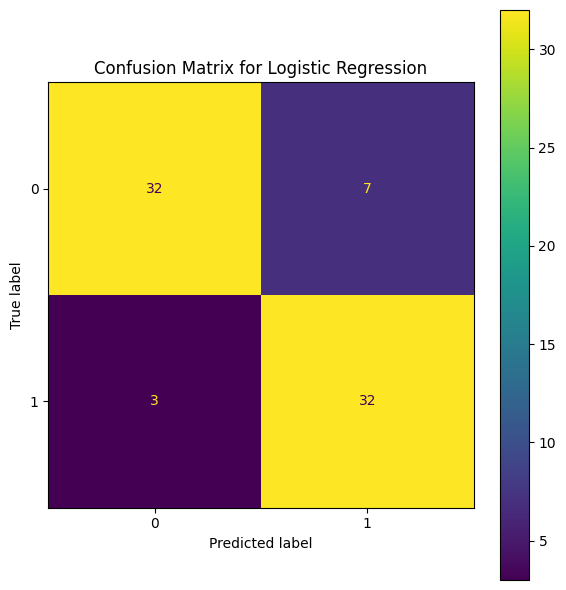

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_val, y_val, ax=ax)
ax.set_title('Confusion Matrix for Logistic Regression')
plt.tight_layout()
plt.show()

In [19]:
cols=["regresion logistica", "Accuracy", "Recall", "Precision", "F1"]
data_table = pd.DataFrame(columns=cols)
pred_proba = clf.predict_proba(X_val)[:, 1]

# confusion matric, cm
cm = confusion_matrix(y_val, pred)

# recall: TP/(TP+FN)
recall = cm[1,1]/(cm[1,1] +cm[1,0])

# precision: TP/(TP+FP)
precision = cm[1,1]/(cm[1,1] +cm[0,1])

# F1 score: TP/(TP+FP)
f1 = 2*recall*precision/(recall + precision)

df = pd.DataFrame([["metricas desempeño", accuracy*100, recall, precision, f1]], columns=cols)
data_table = pd.concat([data_table, df], ignore_index=True)

np.round(data_table.reset_index(drop=True), 2)

,regresion logistica,Accuracy,Recall,Precision,F1
0,metricas desempeño,86.49,0.91,0.82,0.86


#Visualización e interpretabilidad de las variables del modelo

In [24]:
explainer = shap.Explainer(clf, X_train, feature_names=X_train.columns)
shap_values = explainer(X_val)

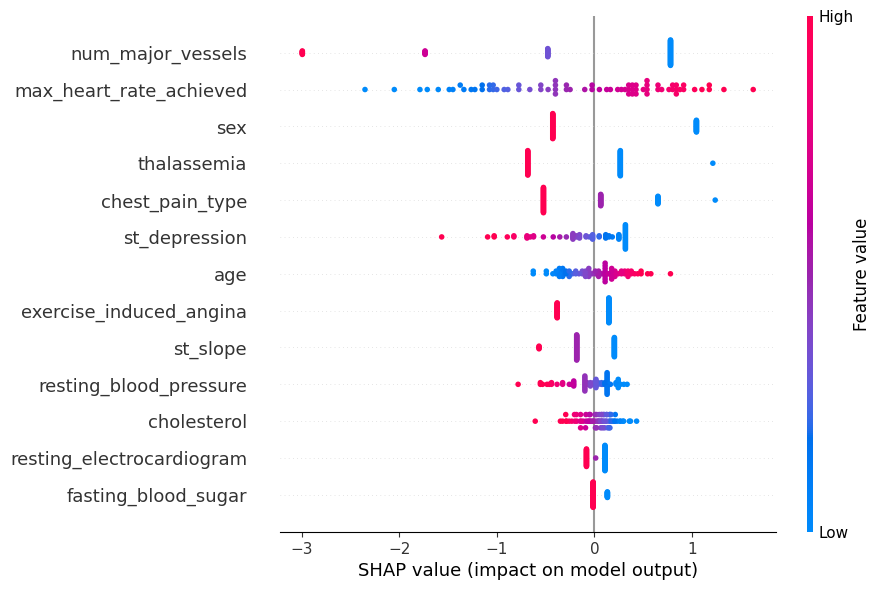

In [27]:
shap.plots.beeswarm(shap_values, max_display = 13)

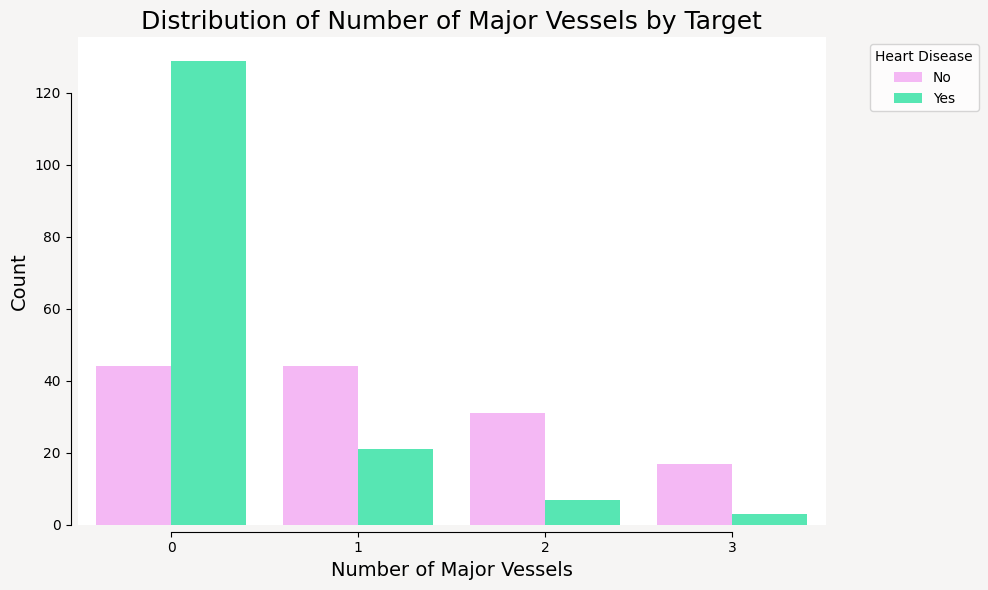

In [40]:
plt.figure(figsize=(10, 6), facecolor='#F6F5F4')
sns.countplot(data=data, x='num_major_vessels', hue='target', palette=mypal[1::4])
plt.title('Distribution of Number of Major Vessels by Target', fontsize=18)
plt.xlabel('Number of Major Vessels', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Heart Disease', labels=['No', 'Yes'], bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(right=True)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.show()

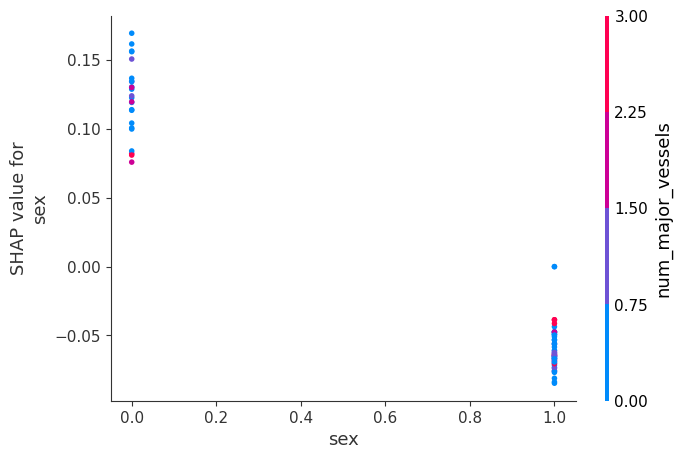

In [36]:
# Visualizing SHAP dependence plot for cholesterol
shap.dependence_plot('sex', shap_values[:, :, 1], X_val)